# Introduction

Context: 
- Game called _Cookie Cats_ wants to change the location of the first gate in the game from level 30 to level 40 to see if this makes a difference in user behavior. To do this, 90189 users that installed the game within a two week period were randomly assigned to each game version. A few variables pertaining to each user were measured, such as the number of game rounds played, and whether the user returned to play the game after one and seven days.

Goal: 
- Find out if having the first gate in the _Cookie Cats_ game at level 30 or level 40 influences the playability of the game. 

Intended audience: 
- These insights will help a product manager to make a decision about which version of the game to implement or keep to maximize the number of games played as well as the retention rate of their players. 

Target metric: 
- Sum_gamerounds: the number of rounds of the _Cookie Cats_ game played by a given player during the first two weeks post game download.

If a difference is found when comparing this variable between the two versions of the game, the version with the highest sum_gamerounds could be chosen as the version with the highest playability. 

- Retention_7: A boolean variable stating whether a player continued playing the game seven days post installation or not. 

The game version with a higher retention rate seven days after installation, is such a difference is noted, could be a more desirable version of the game as more users will keep playing it.  

Project Flow: 
- Introduction
- Importing necessary libraries
- Data loading
- Exploratory Data Analysis 
- Assumptions Checking
- A/B Testing
- Decision

## Importing libraries and data: 

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pylab as plt
import scipy.stats as stats
import statsmodels.api as sm
import pylab as py
from functions import bootstrap_means, bootstrap_medians, plot_cdf_by_group

%matplotlib inline

Taking an initial look at the data: 

In [2]:
cc = pd.read_csv("cookie_cats.csv", sep=",")
cc

,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True
...,...,...,...,...,...
90184,9999441,gate_40,97,True,False
90185,9999479,gate_40,30,False,False
90186,9999710,gate_30,28,True,False
90187,9999768,gate_40,51,True,False


There are a little over 90 000 entries in five columns. 

# Initial Data Exploration

To be able to properly perform statistical testing, it is important to examine the data first. The first step is to look at the data types present: 

In [3]:
cc.dtypes

userid             int64
version           object
sum_gamerounds     int64
retention_1         bool
retention_7         bool
dtype: object

Two of the variables are numberical, and the version variable is an object. The player retention variables are boolean. Next, checking to see if there are any missing values: 

In [4]:
cc.isnull().any()

userid            False
version           False
sum_gamerounds    False
retention_1       False
retention_7       False
dtype: bool

There are no missing values. 

Duplicate entries? 
- Check using user ID

In [5]:
cc.duplicated(subset=["userid"]).any()

np.False_

There are no duplicate entries. Looking at the total number of users: 

In [6]:
total_users = len(cc)
total_users

90189

The total sample size is 90189 participants.

## Variable Exploration

Defining a function to look at categorical percentages out of total users:

In [7]:
def percentage(var):
    return (var / total_users) * 100

Now, variables can be explored one by one. This will be useful to be able to understand how distributions look and if there is a potential for correlation between variables before performing statistical tests.

### Game version distribution: 


This is an important variable to examine, because this is how players were assigned to each group of the experiment. Therefore, it will be necessary to check for any potential sample ratio mismatches (SRM). The proportion of players who played the game with version gate_30 and gate_40 respectively, are:

In [8]:
gate_dist = (
    cc["version"].value_counts().rename_axis("version").to_frame("Counts")
)
gate_dist["percentage"] = gate_dist["Counts"].apply(percentage)
gate_dist

,Counts,percentage
version,,
gate_40,45489,50.437415
gate_30,44700,49.562585


Defining a variable for each game version: 

In [9]:
g_30 = cc[cc["version"] == "gate_30"]
g_40 = cc[cc["version"] == "gate_40"]

If there were the same ratio of users in each group, then the expected number of players per group would be: 

In [10]:
exp_num = (gate_dist["Counts"].loc["gate_30"] + gate_dist["Counts"].loc["gate_40"]) / 2
exp_num

np.float64(45094.5)

It will be necessary to check for sample ratio mismatch (SRM) here, as the gate variable is where users are spit into two groups. 

To check for SRM, it is possible to do a chi-squared test: 

In [11]:
s = [gate_dist["Counts"].loc["gate_30"], gate_dist["Counts"].loc["gate_40"]]
n = len(s)
exp_size = [sum(s) / n for _ in range(n)]

chi = stats.chisquare(s, exp_size)
if chi[1] < 0.01:
    print("SRM warning")
else:
    print("Probably no SRM")

SRM warning


As a SRM warning is present, any possible biases should be examined. As the data has already been collected and sampling methods are unknown, this might be tricky. 

 However, since the respective proportions of players with gate 30 and 40 are 49.6% and 50.4%, then this mismatch might not be too threatening for the integrity of the experiment. 

 Continuing to examine the rest of the variables: 

### Player Retention 

Looking at the proportions of players who played the game after one day post install: 

In [12]:
ret_1 = (
    cc["retention_1"]
    .value_counts()
    .rename_axis("retention_1")
    .to_frame("Counts")
)
ret_1["Percentage"] = ret_1["Counts"].apply(percentage)
ret_1

,Counts,Percentage
retention_1,,
False,50036,55.47905
True,40153,44.52095


About 45% of players came back to play the game one day after installation.

Looking at the amount of players that came back to play after seven days post install: 

In [13]:
ret_7 = (
    cc["retention_7"]
    .value_counts()
    .rename_axis("retention_7")
    .to_frame("Counts")
)
ret_7["Percentage"] = ret_7["Counts"].apply(percentage)
ret_7

,Counts,Percentage
retention_7,,
False,73408,81.393518
True,16781,18.606482


About 19% of players came back to play the game one week after installation.

Moving on to look at the number of game rounds played, which is the target metric: 

### Game Rounds Played

In [14]:
game_rounds = (
    cc["sum_gamerounds"]
    .value_counts()
    .sort_index()
    .rename_axis("sum_gamerounds")
    .to_frame("Counts")
)
game_rounds["Percentage"] = game_rounds["Counts"].apply(percentage)
game_rounds

,Counts,Percentage
sum_gamerounds,,
0,3994,4.428478
1,5538,6.140438
2,4606,5.107053
3,3958,4.388562
4,3629,4.023772
...,...,...
2294,1,0.001109
2438,1,0.001109
2640,1,0.001109


Most players play few rounds of _Cookie Cats_, while few players play many rounds. One player played 49854 game rounds. This could be an error, or it could be one player who was extremely dedicated to the game. 

In [15]:
cc.sum_gamerounds.describe()

count    90189.000000
mean        51.872457
std        195.050858
min          0.000000
25%          5.000000
50%         16.000000
75%         51.000000
max      49854.000000
Name: sum_gamerounds, dtype: float64

Most people have played between 5 and 51 rounds of _Cookie Cats_, and many outliers (25% of all players) have played more rounds than this during the first two weeks after game installation.

Looking at outliers: 

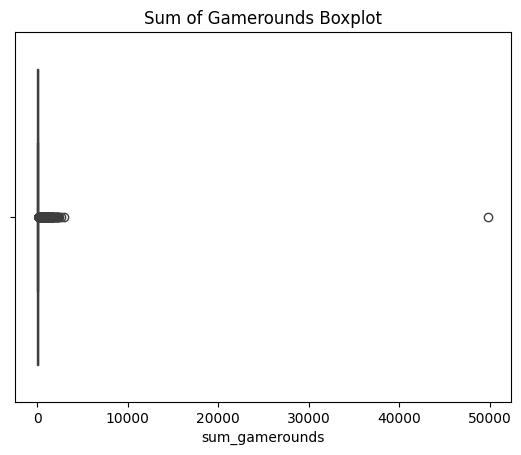

In [16]:
sns.boxplot(x=cc["sum_gamerounds"]).set(title="Sum of Gamerounds Boxplot");

Many outliers are present, so looking at them in a list: 

In [17]:
Q1 = cc["sum_gamerounds"].quantile(0.25)
Q3 = cc["sum_gamerounds"].quantile(0.75)
IQR = Q3 - Q1
threshold = 1.5
outliers = cc[
    (cc["sum_gamerounds"] < Q1 - threshold * IQR)
    | (cc["sum_gamerounds"] > Q3 + threshold * IQR)
]
outliers = outliers.sort_values(by=["sum_gamerounds"], ascending=False)
outliers.head()

,userid,version,sum_gamerounds,retention_1,retention_7
57702,6390605,gate_30,49854,False,True
7912,871500,gate_30,2961,True,True
29417,3271615,gate_40,2640,True,False
43671,4832608,gate_30,2438,True,True
48188,5346171,gate_40,2294,True,True


In total, there are 10177 outliers with over 120 game rounds played. One person has played almost 50 000 game rounds, which is far higher than all other values. Therefore, this outlier is removed, and all other outliers will be kept to ensure that there is no loss of information.

In [18]:
max_gamerounds = cc["sum_gamerounds"].max()
cc = cc[cc["sum_gamerounds"] != max_gamerounds]

Examining the boxplot again: 

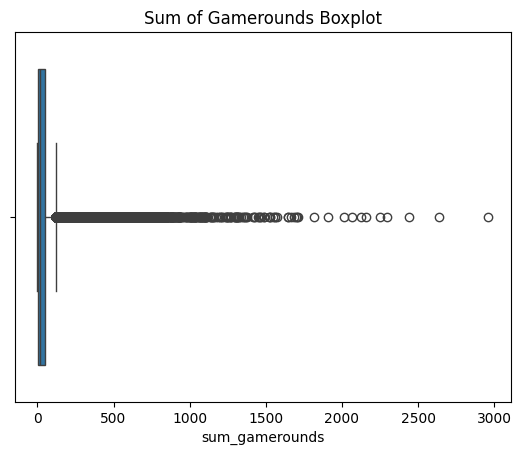

In [19]:
sns.boxplot(x=cc["sum_gamerounds"]).set(title="Sum of Gamerounds Boxplot");

The data is still heavily skewed to the right. Looking at the distribution of the counts of the number of game rounds played separated into groups will help to better understand the data: 

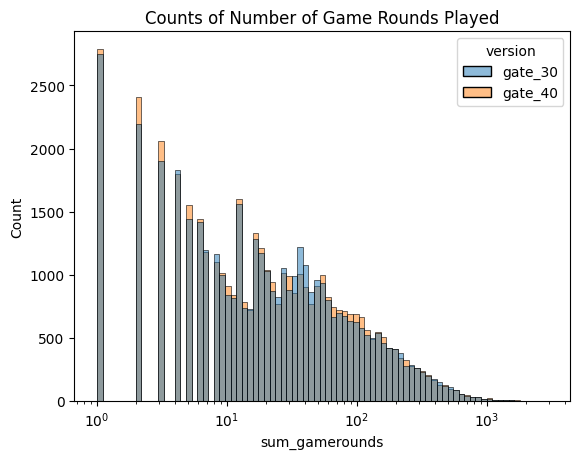

In [20]:
sns.histplot(data=cc, x="sum_gamerounds", hue="version", log_scale=True).set(
    title="Counts of Number of Game Rounds Played"
);

Here, a log scale is used to permit better visualization. This data is heavily skewed to the right with many outliers having total game rounds over 120. This does not look like a normal distribution, even when using a log scale, which means that statistical tests assuming normality will likely not be used. 

Defining variables for each game version to help with analysis later on: 

In [21]:
g_30 = cc[cc["version"] == "gate_30"]
g_40 = cc[cc["version"] == "gate_40"]

Looking briefly at summary statistics for each group is important to identify possible differences between the game versions: 

In [22]:
g_30.describe()

,userid,sum_gamerounds
count,4.469900e+04,44699.000000
mean,4.987532e+06,51.342111
std,2.881051e+06,102.057598
min,1.160000e+02,0.000000
25%,2.505463e+06,5.000000
50%,4.983630e+06,17.000000
75%,7.481522e+06,50.000000
max,9.999710e+06,2961.000000


In [23]:
g_40.describe()

,userid,sum_gamerounds
count,4.548900e+04,45489.000000
mean,5.009073e+06,51.298776
std,2.885496e+06,103.294416
min,3.770000e+02,0.000000
25%,2.517171e+06,5.000000
50%,5.007329e+06,16.000000
75%,7.510762e+06,52.000000
max,9.999861e+06,2640.000000


Upon observation, it is seen that: 

mean: 
- g_30: 52.5, 
- g_40: 51.3

median: 
- g_30: 17
- g_40: 16

The mean for the g_30 group is higher, most likely because of the large outliers for the number of game rounds played. The median is also higher in the g_30 group.

# Normality Assumption Examination

In order to perform statistical tests to help with A/B testing, it is necessary to look at the normality of the data. This will help to choose which tests are performed.

A quantile-quantile plot can help to show if this data is normally distributed: 

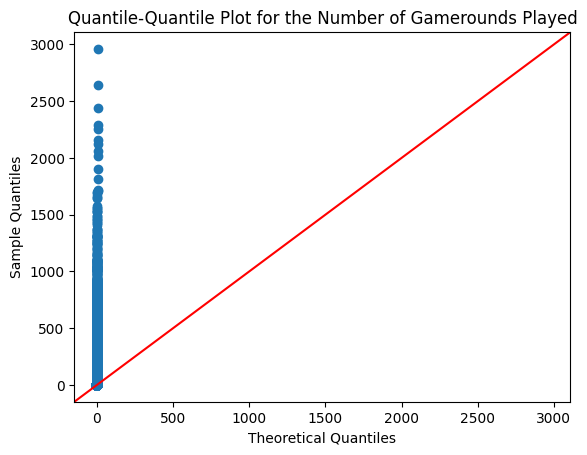

In [24]:
sm.qqplot(cc["sum_gamerounds"], line="45")
plt.title("Quantile-Quantile Plot for the Number of Gamerounds Played")
py.show()

This data does not look normal at all, as it does not follow a straight line here. This is no surprise, as the histogram of the data also did not show normality.

In addition, a Kolmogorov-Smirnov test at the 95% confidence level could show the non-normality of this data. Here, the null hypothesis is that the distribution is normal and the alternative hypothesis is that the distribution is not normal. 

In [25]:
stat, pval = stats.kstest(cc["sum_gamerounds"], "norm")
print(f"p value: ", pval)
if pval < 0.05:
    print(
        "According to the Kolmogorov-Smirnov test, this distribution cannot be assumed to be normal."
    )
else:
    print("Normality can be assumed.")

p value:  0.0
According to the Kolmogorov-Smirnov test, this distribution cannot be assumed to be normal.


As the p value from this test is zero, this again shows that the game rounds variable does not follow a normal distribution. 

Now, the data could be transformed using a Box Cox transformation to see this induces normality. This could be helpful in order to perform statistical tests that assume normality, such as the student t test. 

In [26]:
fitted_data, fitted_lambda = stats.boxcox(cc["sum_gamerounds"] + 1)

print(f"Lambda value used for Transformation: {fitted_lambda}")

Lambda value used for Transformation: -0.02993256224468489


Visualizing this transformation gives: 

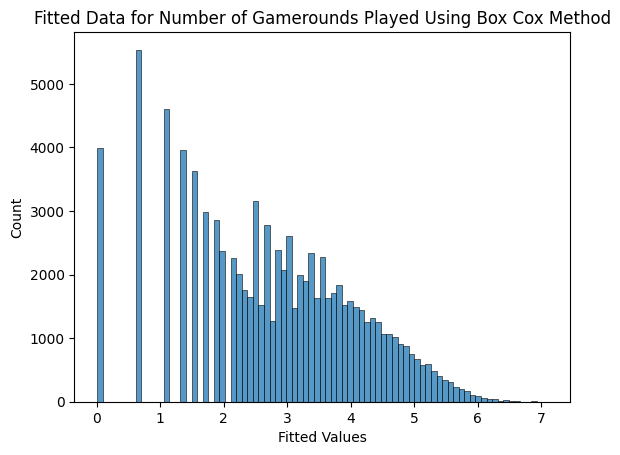

In [27]:
sns.histplot(fitted_data).set(
    title="Fitted Data for Number of Gamerounds Played Using Box Cox Method",
    xlabel="Fitted Values",
);

This data still does not look normally distributed. Looking at a QQ plot will show this more clearly: 

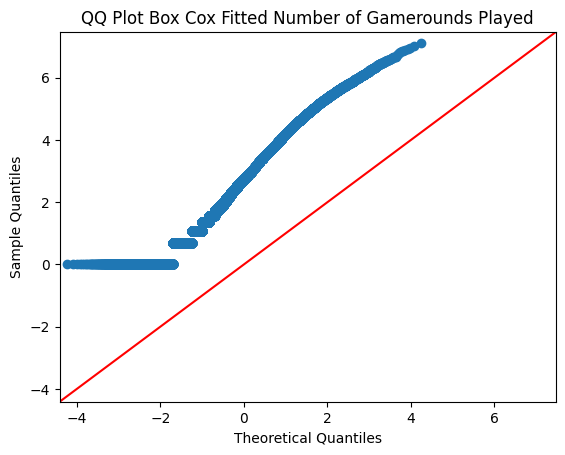

In [28]:
sm.qqplot(fitted_data, line="45")
plt.title("QQ Plot Box Cox Fitted Number of Gamerounds Played")
py.show()

From the histogram and the QQ plot, it seems that the Box Cox transformation has not induced normality in the distribution. Performing a Kolmogorov-Smirnov test, where the null hypothesis assumes normality and the alternative hypothesis is that the data is not a normal distribution gives: 

In [29]:
stats.kstest(fitted_data, "norm")
print(f"p value: ", pval)
if pval < 0.05:
    print(
        "According to the Kolmogorov-Smirnov test, this distribution cannot be assumed to be normal."
    )
else:
    print("Normality can be assumed.")

p value:  0.0
According to the Kolmogorov-Smirnov test, this distribution cannot be assumed to be normal.


This data is still not normally distributed, even after the Box Cox transformation. Therefore, non parametric tests will be used for analysis.

# A/B Testing

Tests that can be done: 
- Bootstrapping for means 
- Bootstrapping for medians
- Kolmogorov-Smirnov Test
- Chi Square Test



The tests will be done at the 95% confidence level.


In [30]:
alpha = 0.05

## Bootstrapping mean comparison

Using bootstrapping is a good option here because no assumptions need to be made about the data. 

Here, n_iterations is the number of iterations for resampling. Then, bootstrapping is used to obtain the mean distribution and a 95% confidence interval is calculated. To do this, the difference between means is first calculated in the diff_means variable: 

In [31]:
n_iterations = 10000
means_g_30, means_g_40 = bootstrap_means(
    g_30["sum_gamerounds"], g_40["sum_gamerounds"], n_iterations
)
diff_means = means_g_30 - means_g_40

lower_ci = np.percentile(diff_means, 2.5)
upper_ci = np.percentile(diff_means, 97.5)

print(
    f"95% Confidence Interval for the difference in means: ({lower_ci:.3f}, {upper_ci:.3f})"
)

95% Confidence Interval for the difference in means: (-1.291, 1.381)


From this confidence interval, one cannot assert that the means between the g_30 and g_40 groups are different. Looking at this a plot for the distribution of the means in each group, and another plot for the difference in the means gives:

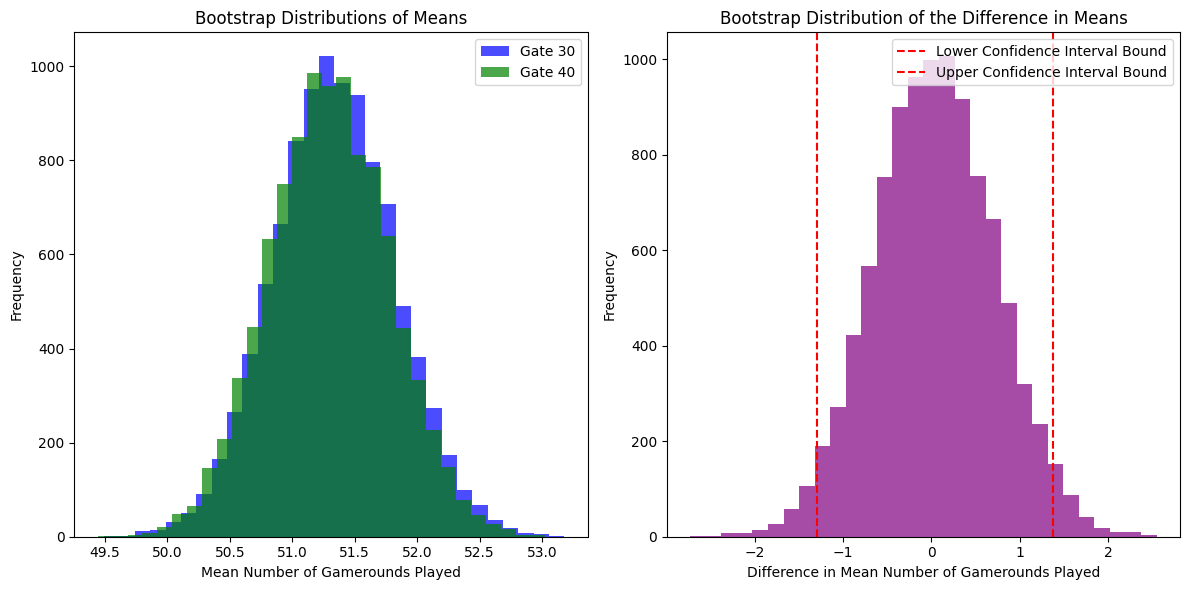

In [32]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.hist(means_g_30, bins=30, alpha=0.7, label="Gate 30", color="blue")
plt.hist(means_g_40, bins=30, alpha=0.7, label="Gate 40", color="green")
plt.legend()
plt.title("Bootstrap Distributions of Means")
plt.xlabel("Mean Number of Gamerounds Played")
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
plt.hist(diff_means, bins=30, alpha=0.7, color="purple")
plt.axvline(
    x=lower_ci, color="red", linestyle="--", label="Lower Confidence Interval Bound"
)
plt.axvline(
    x=upper_ci, color="red", linestyle="--", label="Upper Confidence Interval Bound"
)

plt.legend()
plt.title("Bootstrap Distribution of the Difference in Means")
plt.xlabel("Difference in Mean Number of Gamerounds Played")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

Now, performing the same test for a difference in medians: 

## Bootstrapping median comparison

Bootstrapping is also used here to evaluate differences between medians in the three groups. This technique is used to give more robust conclusions to the first bootstrapping method. Here, the obs_diff_median variable is the difference between medians, and n_iterations is the number of iterations. Then, a 95% confidence interval is calculated: 

In [33]:
n_iterations = 10000

medians_g_30, medians_g_40 = bootstrap_medians(
    g_30["sum_gamerounds"], g_40["sum_gamerounds"], n_iterations
)
diff_medians = medians_g_30 - medians_g_40
observed_diff_median = np.median(g_30["sum_gamerounds"]) - np.median(
    g_40["sum_gamerounds"]
)

lower_ci = np.percentile(diff_medians, 2.5)
upper_ci = np.percentile(diff_medians, 97.5)

print(
    f"95% Confidence Interval for the difference in medians: ({lower_ci:.3f}, {upper_ci:.3f})"
)

95% Confidence Interval for the difference in medians: (0.000, 1.000)


Again, the 95% confidence interval shows that one cannot say that the medians between the g_30 and g_40 groups are different here. Now, plotting the boostrap distribution of medians for each group and then the bootstrap distribution of the difference in medians gives: 

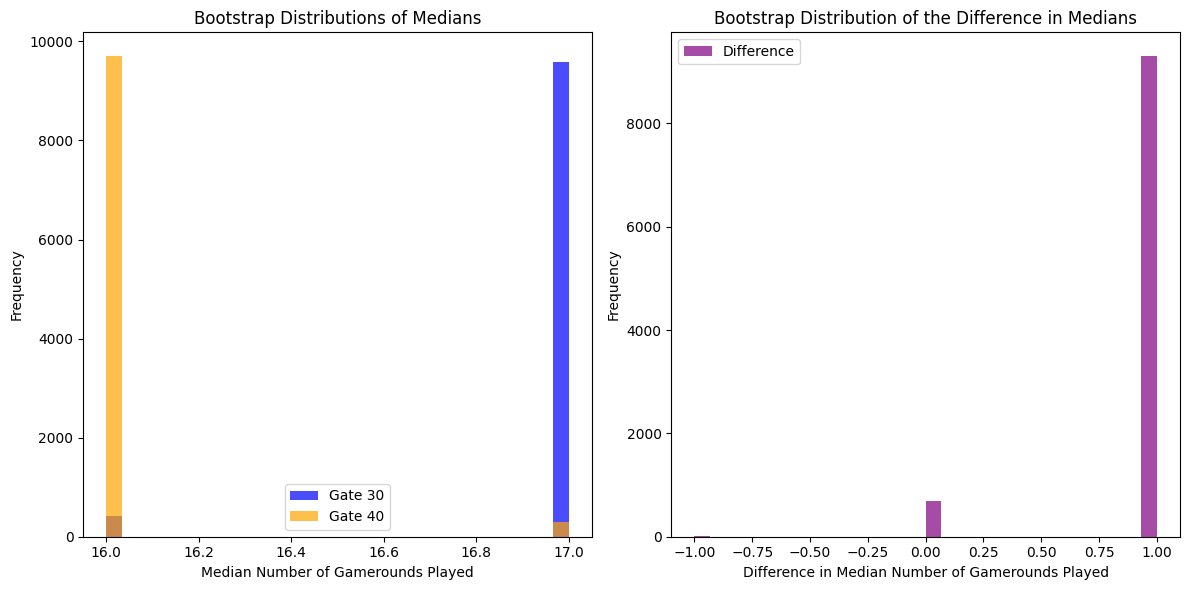

In [34]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.hist(medians_g_30, bins=30, alpha=0.7, label="Gate 30", color="blue")
plt.hist(medians_g_40, bins=30, alpha=0.7, label="Gate 40", color="orange")
plt.legend()
plt.title("Bootstrap Distributions of Medians")
plt.xlabel("Median Number of Gamerounds Played")
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
plt.hist(diff_medians, bins=30, alpha=0.7, label="Difference", color="purple")
plt.legend()
plt.title("Bootstrap Distribution of the Difference in Medians")
plt.xlabel("Difference in Median Number of Gamerounds Played")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

These plots show that after repeated sampling, the median for group A (g_30) is generally 17 and the median for group B (g_40) is generally 16. However, this is still not enough to show a significant difference between the two groups.

## Kolmogorov-Smirnov test 

This is a non parametric test to see if the two samples could be from the same distribution or not. This test will help to indicate if there is a significant difference in the number of game rounds played between the g_30 and g_40 variables, at the 95% confidence level, as bootstrapping has given ambiguous conclusions.

For this test, null hypothesis states that there is no difference between the two groups, and the alternate hypothesis states that there is a significant difference between the two groups at the 95% confidence level. 

In [35]:
alpha = 0.05
statistic, p_value = stats.ks_2samp(g_30["sum_gamerounds"], g_40["sum_gamerounds"])
print("p value: ", p_value)
if p_value < alpha:
    print("Reject null hypothesis; there is a significant difference")
else:
    print("Fail to reject the null hypothesis; there is no significant difference")

p value:  0.01727609923280408
Reject null hypothesis; there is a significant difference


Now that a significant difference between the two groups has been found, this test will be repeated to discover the larger of the two groups. Therefore, the null hypothesis is that g_40 is larger or equal to g_30, and the alternate hypothesis is that g_30 is larger than g_40. 

In [36]:
statistic, p_value = stats.ks_2samp(
    g_30["sum_gamerounds"], g_40["sum_gamerounds"], alternative="less"
)
print("p value: ", p_value)

if p_value < alpha:
    print("Reject null hypothesis; there is a significant difference")
else:
    print("Fail to reject the null hypothesis; there is no significant difference")

p value:  0.008608886539256512
Reject null hypothesis; there is a significant difference


This indicates that the version of the game with the first gate at level 30 is shifted towards larger values than the version with the first gate at level 40. It is important to remember here that the g_30 version had a large outlier, which could influence this difference.

Examining these insights with a cumulative distribution function plot: 

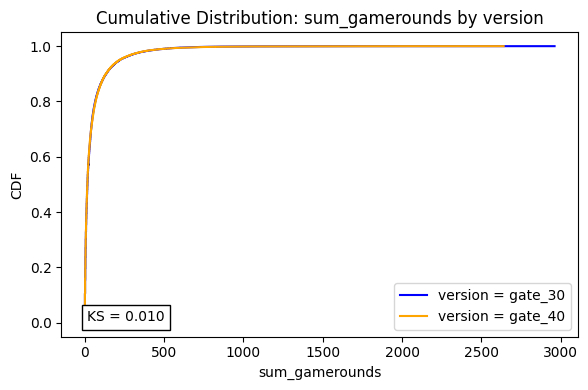

In [37]:
fig, ax = plt.subplots(figsize=(6, 4))

plot_cdf_by_group(
    df=cc,
    value_col="sum_gamerounds",
    group_col="version",
    group_a="gate_30",
    group_b="gate_40",
    ax=ax,
)

plt.tight_layout()
plt.show()


This plot indicates that distributions for both game versions are very similar. The difference detected with the previous KS tests is likely due to the fact that the sample size is large.

## Chi-squared test for difference in retention_7

As bootstrapping has not shown a significant difference between game versions, and the Kolmogorov-Smirnov test has shown a significant difference between game versions, another statistical test is important to begin to make a decision about which game version is best. A chi-squared test can be performed to look at the retention rates after seven days in g_30 and g_40. The game version with the highest retention rate after seven days is desirable to keep. 

First, a table showing this data is made: 

In [39]:
crosstab = pd.crosstab(cc["retention_7"], cc["version"])
crosstab

version,gate_30,gate_40
retention_7,,
False,36198,37210
True,8501,8279


Here is a table of users who still play the game ("True") or who have not played the game ("False") after seven days looking at the two game versions. Upon initial examination, it seems that more users stay with the game after a week with the gate at level 30, though it is important to remember that this could be incorrect due to the sample mismatch ratio that was present.

For this chi squared test, the null hypothesis is that there is no significant difference between the two groups, and the alternative hypothesis is that there is a significant difference between the two groups.

In [40]:
chi2, p_val, dof, expected = stats.chi2_contingency(crosstab)
alpha = 0.05
print("p value is " + str(p_val))
if p_val < alpha:
    print("Reject null hypothesis; there is a significant difference")
else:
    print("Fail to reject the null hypothesis; there is no significant difference")

p value is 0.001639125967865441
Reject null hypothesis; there is a significant difference


It seems that there is a significant difference between g_30 and g_40's seven day retention numbers. This suggests that keeping the first gate at level 30 will not negatively impact player retention after one week.

# Decision and Conclusions

From these tests, there is not enough evidence to say there is a significant difference between having the first gate in the _Cookie Cats_ game at level 40 or level 30. For example: 

- The bootstrapping tests did not show statistical differences between the two versions looking at the number of game rounds played.
- Also for the number of game rounds played, the Kolmogorov-Smirnov test showed that the version of the game with the first gate at level 30 was shifted towards higher values than the one with the first gate at level 40. It is important to keep in mind here that this was the version with an abnormally high outlier for the number of game rounds played. 
- When looking at if players continued playing the game after one week or not, the chi-squared test showed that the version with the first gate at level 30 had slightly better retention than the version with the first gate at level 40. 

Therefore, this data shows that it is best to keep the first gate in the game at level 30 for player retention and the number of game rounds played, which directly influences the amount of money that the _Cookie Cats_ game company will make from this game. 

One important note is that these conclusions could be false, as a sample ratio mismatch was found post data collection.